# 4.5. Concise Implementation of Softmax Regression

In this chapter we'll see how to implement softmax regression with MindSpore to train our model on the Fashion MNIST dataset from the previous chapter.

Assume the dataset is already loaded under `data/fashion/` and initialize MindSpore to use the Ascend 310B1 chip on our OrangePi AIpro \(20T\) development board.

In [1]:
import mindspore
mindspore.set_device(device_target='Ascend', device_id=0)

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

## 4.5.1. Defining the Model

Let's define our model as a neural network with a single fully connected layer consisting of $28\times28=784$ input channels and $10$ output channels. We must also flatten our images with [`mindspore.ops.Flatten`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/ops/mindspore.ops.flatten.html) before passing through our fully connected layer.

In [2]:
from mindspore import dtype as mstype
import mindspore.nn as nn
import mindspore.ops as ops

class MyModel(nn.Cell):
    def __init__(self, lr=0.1):
        super().__init__()
        self.lr = lr
        self.flatten = ops.Flatten()
        self.dense1 = nn.Dense(784, 10, dtype=mstype.float16)

    def construct(self, X):
        X_flatten = self.flatten(X)
        y_hat = self.dense1(X_flatten)
        return y_hat

model = MyModel(lr=0.1)
model

MyModel(
  (dense1): Dense(input_channels=784, output_channels=10, has_bias=True)
)

Let's also load our dataset as separate training and validation sets.

In [3]:
import mindspore.dataset as ds

dataset_dir = 'data/fashion/'
train_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='train', shuffle=True)
test_ds = ds.FashionMnistDataset(dataset_dir=dataset_dir, usage='test', shuffle=True)

Apply the following transformations to each image.

1. Resize images to size $28\times28$ pixels
1. Rescale pixel values from integer in range $[0,255]$ to float in range $[0,1]$
1. Change the shape of each image from form `(height, width, channels)` to form `(channels, height, width)`. Since our image height and width are both $28$ with grayscale pixels `channels=1`, the shape is transformed from `(28, 28, 1)` to `(1, 28, 28)`. This is given by the class [`mindspore.dataset.vision.HWC2CHW`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/dataset_vision/mindspore.dataset.vision.HWC2CHW.html)

Apply the following transformations to each label.

1. One-hot encoding of labels with [`mindspore.dataset.transforms.OneHot`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/dataset_transforms/mindspore.dataset.transforms.OneHot.html). Since we have a total of 10 catregories of clothing, set `num_classes=10`

In [4]:
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as transforms

def transform_and_batch(dataset):
    image_operations = [
        vision.Resize(size=(28, 28)),
        vision.Rescale(rescale=1/255, shift=0),
        vision.HWC2CHW()
    ]
    label_operations = [
        transforms.OneHot(num_classes=10)
    ]
    dataset = dataset.map(operations=image_operations, input_columns=['image'])
    dataset = dataset.map(operations=label_operations, input_columns=['label'])
    dataset = dataset.batch(batch_size=512, drop_remainder=False)
    return dataset

train_ds = transform_and_batch(train_ds)
test_ds = transform_and_batch(test_ds)

## 4.5.2. Softmax Revisited

To avoid numerical overflow and underflow when computing exponentials and logarithms respectively, we combine the softmax activation and cross-entropy loss function into a single operation [`mindspore.nn.SoftmaxCrossEntropyWithLogits`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.SoftmaxCrossEntropyWithLogits.html). By applying appropriate algebraic simplification on the combined operation, the resulting operation is numerically stable and avoids the risk of overflow or underflow in floating point operations leading to `NaN` values.

## 4.5.3. Training

Define our loss function as below.

In [5]:
loss_fn = nn.SoftmaxCrossEntropyWithLogits(reduction='mean')
loss_fn

SoftmaxCrossEntropyWithLogits()

Use minibatch SGD as our optimizer function and pass in our model parameters for training.

In [6]:
optimizer = nn.SGD(params=model.trainable_params(), learning_rate=model.lr)
optimizer

SGD()

Define our forward and gradient functions.

In [7]:
def forward_fn(X, y):
    y_hat = model(X)
    loss = loss_fn(y_hat, y)
    return loss, y_hat

grad_fn = mindspore.value_and_grad(fn=forward_fn, grad_position=None, weights=optimizer.parameters, has_aux=True)

Now define the training step on a single batch `train_batch` and over a complete epoch `train_epoch`.

In [8]:
def train_batch(X_batch, y_batch):
    (loss, _), grads = grad_fn(X_batch, y_batch)
    optimizer(grads)
    return loss

def train_epoch(epoch=0):
    print(f'Epoch {epoch} start')
    batch_count = train_ds.get_dataset_size()
    training_losses = []
    model.set_train()
    for batch_idx, (X_batch, y_batch) in enumerate(train_ds.create_tuple_iterator()):
        loss = train_batch(X_batch.astype(dtype=mstype.float16), y_batch.astype(dtype=mstype.float16))
        if batch_idx % 10 == 0:
            print(f'Training loss: {loss.asnumpy():.4f} [{batch_idx}/{batch_count}]')
        training_losses.append(loss)
    print(f'Epoch {epoch} end')
    return training_losses

Define a validation function `validate_epoch` to output the validation loss after each epoch as well.

In [9]:
def validate_epoch(epoch=0):
    X_val, y_val = [], []
    for _, (X_batch, y_batch) in enumerate(test_ds.create_tuple_iterator()):
        X_val.append(X_batch.astype(dtype=mstype.float16))
        y_val.append(y_batch.astype(dtype=mstype.float16))
    X_val, y_val = ops.cat(X_val, axis=0), ops.cat(y_val, axis=0)
    model.set_train(False)
    y_hat = model(X_val)
    validation_loss = loss_fn(y_hat, y_val)
    print(f'Validation loss at epoch {epoch}: {validation_loss.asnumpy():.4f}')
    return validation_loss

Train our model using the functions defined above. We also output the validation loss at the end of each epoch.

In [10]:
training_losses, validation_losses = [], []
epochs = 10
for epoch in range(epochs):
    training_losses.extend(train_epoch(epoch=epoch))
    validation_losses.append(validate_epoch(epoch=epoch))
training_losses, validation_losses = ops.stack(training_losses, axis=0), ops.stack(validation_losses, axis=0)
training_losses, validation_losses

Epoch 0 start


/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

.Training loss: 2.2695 [0/118]
Training loss: 1.2979 [10/118]
Training loss: 1.0664 [20/118]
Training loss: 0.9766 [30/118]
Training loss: 0.9028 [40/118]
Training loss: 0.8477 [50/118]
Training loss: 0.7964 [60/118]
Training loss: 0.8154 [70/118]
Training loss: 0.7646 [80/118]
Training loss: 0.6797 [90/118]
Training loss: 0.7686 [100/118]
Training loss: 0.6924 [110/118]
Epoch 0 end
Validation loss at epoch 0: 0.7246
Epoch 1 start
Training loss: 0.7046 [0/118]
Training loss: 0.6509 [10/118]
Training loss: 0.6548 [20/118]
Training loss: 0.6528 [30/118]
Training loss: 0.6904 [40/118]
Training loss: 0.6187 [50/118]
Training loss: 0.6006 [60/118]
Training loss: 0.6606 [70/118]
Training loss: 0.6108 [80/118]
Training loss: 0.6182 [90/118]
Training loss: 0.7021 [100/118]
Training loss: 0.6343 [110/118]
Epoch 1 end
Validation loss at epoch 1: 0.6592
Epoch 2 start
Training loss: 0.6367 [0/118]
Training loss: 0.6309 [10/118]
Training loss: 0.6294 [20/118]
Training loss: 0.5430 [30/118]
Training

(Tensor(shape=[1180], dtype=Float16, value= [ 2.2695e+00,  2.0352e+00,  1.8701e+00 ...  4.7559e-01,  4.9658e-01,  5.1318e-01]),
 Tensor(shape=[10], dtype=Float16, value= [ 7.2461e-01,  6.5918e-01,  6.0205e-01,  5.7471e-01,  5.5566e-01,  5.5078e-01,  5.3271e-01,  5.1904e-01,  5.1074e-01,  5.0928e-01]))

Plot the training vs. validation losses with Matplotlib.

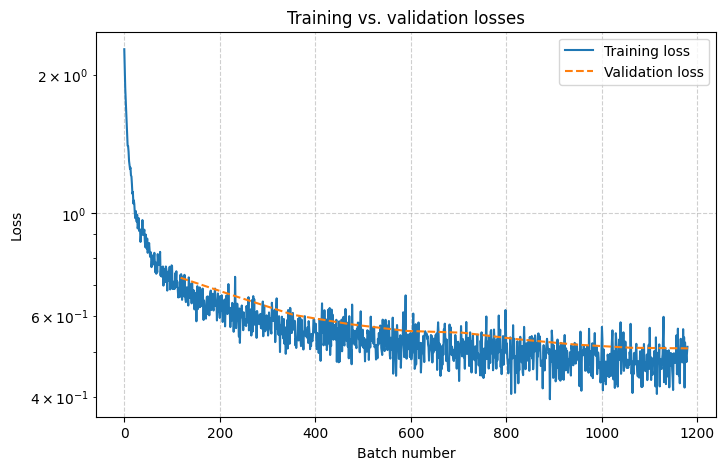

In [11]:
import matplotlib.pyplot as plt
import numpy as np

batches_per_epoch = 118
batch_x = np.arange(epochs * batches_per_epoch)
epoch_x = np.arange(epochs) * batches_per_epoch + batches_per_epoch
training_losses_y = training_losses.asnumpy()
validation_losses_y = validation_losses.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(batch_x, training_losses_y, label='Training loss', linestyle='-')
plt.plot(epoch_x, validation_losses_y, label='Validation loss', linestyle='--')

plt.title('Training vs. validation losses')
plt.xlabel('Batch number')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

Since we're interested in the accuracy of our model, let's compute the validation accuracy - what proportion of images from the validation set can it predict the correct labels?

In [12]:
X_val, y_val = [], []
for _, (X_batch, y_batch) in enumerate(test_ds.create_tuple_iterator()):
    X_val.append(X_batch.astype(dtype=mstype.float16))
    y_val.append(y_batch.astype(dtype=mstype.float16))
X_val, y_val = ops.cat(X_val, axis=0), ops.cat(y_val, axis=0)
model.set_train(False)
y_hat = np.argmax(model(X_val).asnumpy(), axis=1)
y_val = np.argmax(y_val.asnumpy(), axis=1)
total = y_val.shape[0]
correct = (y_hat == y_val).sum()
accuracy = correct / total
accuracy

0.8255

Our trained model has accuracy just over $80\%$ - not bad!

## 4.5.4. Summary

In this chapter, we saw how to train a linear classification model on the Fashion MNIST dataset to predict labels.